# Macro Indicator Time-Series Forecasting

Standalone notebook for quarterly ARIMA, SARIMA, Exponential Smoothing/ETS, Drift, Log-ARIMA, and Log-SARIMA backtesting and forecasting of macro indicators used in the revenue-forecasting project.

The five macro indicators are **CPI**, the **10-year Treasury yield (DGS10)**, **Brent oil**, **NASDAQ** and the **S&P 500**. Each one is aggregated to quarterly means, then several classical models are tuned and backtested on the last 8 quarters, and the chosen model forecasts the indicator until 2032.

The forecasts are saved as `macro_forecasts_for_company_models.csv` and are used as extra features (scenarios 3 and 4) in the main notebook.

The source CSVs (FRED series and an S&P 500 export) are not included in the repo, the outputs of the last run are saved in the notebook.

In [2]:
import json
import warnings
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

warnings.filterwarnings("ignore")
plt.style.use("ggplot")

COMPANY_DATA_DIR = Path("company data")
RESULTS_DIR = Path("experiment_results") / "macro_time_series_forecasts"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

FORECAST_END_DATE_2032 = pd.Timestamp("2032-12-31")


## Loading the macro series

FRED files (CPI, DGS10, Brent, NASDAQ) share one format, the S&P 500 file is a different export and has its own loader.

In [3]:
# The S&P 500 file has a different layout (vendor export) than the FRED files, that's why it has its own loader
def csv_path(filename, fallback_filename=None):
    candidates = [Path(filename), COMPANY_DATA_DIR / filename]
    if fallback_filename is not None:
        candidates.extend([Path(fallback_filename), COMPANY_DATA_DIR / fallback_filename])

    for candidate in candidates:
        if candidate.exists():
            return candidate

    return COMPANY_DATA_DIR / filename


MACRO_SPECS = {
    "CPI": {
        "path": csv_path("CPIAUCSL.csv"),
        "source_col": "CPIAUCSL",
        "loader": "fred",
    },
    "DGS10": {
        "path": csv_path("DGS10.csv"),
        "source_col": "DGS10",
        "loader": "fred",
    },
    "BRENT": {
        "path": csv_path("brent.csv"),
        "source_col": "POILBREUSDM",
        "loader": "fred",
    },
    "NASDAQ": {
        "path": csv_path("NASDAQCOM.csv"),
        "source_col": "NASDAQCOM",
        "loader": "fred",
    },
    "SP500": {
        "path": csv_path("S&P index.csv", fallback_filename="S&P index (1).csv"),
        "source_col": "Close",
        "loader": "sp500_vendor",
    },
}

for name, spec in MACRO_SPECS.items():
    print(name, "->", spec["path"], "exists=", spec["path"].exists())

CPI -> company data/CPIAUCSL.csv exists= True
DGS10 -> company data/DGS10.csv exists= True
BRENT -> company data/brent.csv exists= True
NASDAQ -> company data/NASDAQCOM.csv exists= True
SP500 -> company data/S&P index.csv exists= True


In [4]:
def load_fred_macro(path, source_col, value_col):
    df = pd.read_csv(path)
    df = df.rename(columns={"observation_date": "date", source_col: value_col})
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df[value_col] = pd.to_numeric(df[value_col].replace(".", np.nan), errors="coerce")
    return df[["date", value_col]].dropna().sort_values("date").reset_index(drop=True)


# the S&P export has some header rows above the table, the real header is the line that starts with 'Exchange Date'
def load_sp500_vendor(path, value_col="SP500"):
    raw = pd.read_csv(path, header=None, dtype=str)
    header_idx = raw.index[raw.iloc[:, 0].astype(str).str.strip().eq("Exchange Date")][0]
    df = pd.read_csv(path, skiprows=header_idx)
    df = df.rename(columns={"Exchange Date": "date", "Close": value_col})
    df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
    df[value_col] = (
        df[value_col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .pipe(pd.to_numeric, errors="coerce")
    )
    return df[["date", value_col]].dropna().sort_values("date").reset_index(drop=True)


def to_quarterly(df, value_col):
    out = df.copy()
    out["date"] = pd.to_datetime(out["date"])
    quarterly = (
        out.set_index("date")[value_col]
        .resample("QE")
        .mean()
        .dropna()
        .rename(value_col)
        .reset_index()
    )
    quarterly["year"] = quarterly["date"].dt.year
    quarterly["quarter"] = quarterly["date"].dt.quarter
    return quarterly[["date", "year", "quarter", value_col]]


macro_quarterly_frames = []
for value_col, spec in MACRO_SPECS.items():
    if spec["loader"] == "fred":
        loaded = load_fred_macro(spec["path"], spec["source_col"], value_col)
    elif spec["loader"] == "sp500_vendor":
        loaded = load_sp500_vendor(spec["path"], value_col=value_col)
    else:
        raise ValueError(f"Unknown loader: {spec['loader']}")

    q = to_quarterly(loaded, value_col)
    macro_quarterly_frames.append(q)
    print(value_col, q["date"].min().date(), "to", q["date"].max().date(), "rows=", len(q))

macro_quarterly = macro_quarterly_frames[0]
for q in macro_quarterly_frames[1:]:
    macro_quarterly = macro_quarterly.merge(q, on=["date", "year", "quarter"], how="outer")

macro_quarterly = macro_quarterly.sort_values("date").reset_index(drop=True)
macro_quarterly.to_csv(RESULTS_DIR / "macro_quarterly_actuals.csv", index=False)
macro_quarterly.tail()

CPI 2008-03-31 to 2026-03-31 rows= 73
DGS10 2008-03-31 to 2025-12-31 rows= 72
BRENT 2008-03-31 to 2026-03-31 rows= 73
NASDAQ 2008-03-31 to 2025-12-31 rows= 72
SP500 2008-03-31 to 2025-12-31 rows= 72


,date,year,quarter,CPI,DGS10,BRENT,NASDAQ,SP500
68,2025-03-31,2025,1,319.475000,4.453607,75.042781,18951.462833,5868.960000
69,2025-06-30,2025,2,320.785667,4.361774,66.955556,18309.732097,5895.233333
70,2025-09-30,2025,3,323.235000,4.261094,68.139386,21441.927656,6496.036667
71,2025-12-31,2025,4,325.547000,4.100000,63.161904,23137.842500,6844.930000
72,2026-03-31,2026,1,326.588000,NaN,64.594091,NaN,NaN


## Models and tuning

ARIMA / SARIMA / ETS / Drift and the log versions. Parameters are tuned with a rolling-origin validation that only uses the training period, models are ranked by sMAPE (ties: MAPE, RMSE, MAE).

In [5]:
# error metrics, the parameter grids and the fit / tune helpers for every model type
METRIC_SORT_ORDER = ["sMAPE", "MAPE", "RMSE", "MAE"]


def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))


def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)


def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred) + 1e-9
    return float(np.mean(2 * np.abs(y_pred - y_true) / denom) * 100)


def metric_row(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "MAE": float(np.mean(np.abs(y_true - y_pred))),
        "RMSE": rmse(y_true, y_pred),
        "MAPE": mape(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred),
    }


ARIMA_GRID = [
    order
    for order in product([0, 1, 2, 3], [0, 1], [0, 1, 2, 3])
    if order != (0, 0, 0)
]

SARIMA_GRID = [
    {"order": order, "seasonal_order": seasonal_order}
    for order in [(0, 1, 1), (1, 1, 0), (1, 1, 1), (2, 1, 1)]
    for seasonal_order in [(0, 0, 0, 4), (1, 0, 0, 4), (0, 1, 1, 4), (1, 1, 1, 4)]
]

ETS_GRID = [
    {"trend": trend, "seasonal": seasonal, "seasonal_periods": 4 if seasonal else None, "damped_trend": damped}
    for trend in [None, "add"]
    for seasonal in [None, "add"]
    for damped in [False, True]
    if not (trend is None and damped)
]

ETS_TREND_GRID = [
    {"trend": "add", "seasonal": seasonal, "seasonal_periods": 4 if seasonal else None, "damped_trend": damped}
    for seasonal in [None, "add"]
    for damped in [False, True]
]

MACRO_MODEL_CANDIDATES = {
    "BRENT": ["ARIMA", "Log-ARIMA"],
    "NASDAQ": ["SARIMA", "Log-SARIMA", "Drift"],
    "SP500": ["SARIMA", "Log-SARIMA", "ETS-trend"],
}

DEFAULT_MACRO_MODEL_CANDIDATES = ["ARIMA", "SARIMA", "ETS"]


DRIFT_INDICATORS = {"BRENT", "NASDAQ", "SP500"}
LOG_MODEL_INDICATORS = {"BRENT", "NASDAQ", "SP500"}


def fit_drift_forecast(train_series, steps):
    series = train_series.dropna().astype(float)
    if len(series) < 2:
        return np.repeat(series.iloc[-1], steps)
    drift = (series.iloc[-1] - series.iloc[0]) / (len(series) - 1)
    horizons = np.arange(1, steps + 1)
    return series.iloc[-1] + drift * horizons


def fit_log_arima_forecast(train_series, steps, order):
    series = train_series.dropna().astype(float)
    if (series <= 0).any():
        raise ValueError("Log-ARIMA requires positive values")
    pred_log = fit_arima_forecast(np.log(series), steps, order)
    return np.exp(pred_log)


def fit_log_sarima_forecast(train_series, steps, order, seasonal_order):
    series = train_series.dropna().astype(float)
    if (series <= 0).any():
        raise ValueError("Log-SARIMA requires positive values")
    pred_log = fit_sarima_forecast(np.log(series), steps, order, seasonal_order)
    return np.exp(pred_log)


def tune_log_arima_order(train_series, n_splits=3, horizon=4, min_train=24):
    series = train_series.dropna().astype(float)
    if (series <= 0).any():
        return (1, 1, 1), pd.DataFrame()

    best_order, results = tune_arima_order(np.log(series), n_splits=n_splits, horizon=horizon, min_train=min_train)
    if not results.empty:
        # Re-score on the original scale so model selection matches final evaluation.
        rescored = []
        splits = rolling_splits(series, n_splits=n_splits, horizon=horizon, min_train=min_train)
        for order in results["order"]:
            fold_metrics = []
            for _, fold_train, fold_valid in splits:
                try:
                    pred = fit_log_arima_forecast(fold_train, len(fold_valid), order)
                    fold_metrics.append(metric_row(fold_valid.values, pred))
                except Exception:
                    continue
            if fold_metrics:
                avg = pd.DataFrame(fold_metrics).mean().to_dict()
                rescored.append({"params": {"order": order}, "order": order, **avg})
        results = pd.DataFrame(rescored)
        if not results.empty:
            results = results.sort_values(METRIC_SORT_ORDER).reset_index(drop=True)
            best_order = results.loc[0, "order"]
    return best_order, results


def tune_log_sarima_params(train_series, n_splits=3, horizon=4, min_train=24):
    series = train_series.dropna().astype(float)
    if (series <= 0).any():
        return {"order": (1, 1, 1), "seasonal_order": (0, 1, 1, 4)}, pd.DataFrame()

    rows = []
    splits = rolling_splits(series, n_splits=n_splits, horizon=horizon, min_train=min_train)
    if not splits:
        return {"order": (1, 1, 1), "seasonal_order": (0, 1, 1, 4)}, pd.DataFrame()

    for params in SARIMA_GRID:
        fold_metrics = []
        for _, fold_train, fold_valid in splits:
            try:
                pred = fit_log_sarima_forecast(
                    fold_train,
                    len(fold_valid),
                    order=params["order"],
                    seasonal_order=params["seasonal_order"],
                )
                fold_metrics.append(metric_row(fold_valid.values, pred))
            except Exception:
                continue

        if fold_metrics:
            avg = pd.DataFrame(fold_metrics).mean().to_dict()
            rows.append({"params": params, **params, **avg})

    results = pd.DataFrame(rows)
    if results.empty:
        return {"order": (1, 1, 1), "seasonal_order": (0, 1, 1, 4)}, results

    results = results.sort_values(METRIC_SORT_ORDER).reset_index(drop=True)
    return {
        "order": results.loc[0, "order"],
        "seasonal_order": results.loc[0, "seasonal_order"],
    }, results


def fit_arima_forecast(train_series, steps, order):
    model = ARIMA(train_series.astype(float), order=order)
    fitted = model.fit()
    return fitted.forecast(steps=steps).values


def fit_sarima_forecast(train_series, steps, order, seasonal_order):
    model = SARIMAX(
        train_series.astype(float),
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fitted = model.fit(disp=False)
    return fitted.forecast(steps=steps).values


def fit_ets_forecast(train_series, steps, params):
    model = ExponentialSmoothing(
        train_series.astype(float),
        trend=params["trend"],
        seasonal=params["seasonal"],
        seasonal_periods=params["seasonal_periods"],
        damped_trend=params["damped_trend"],
        initialization_method="estimated",
    )
    fitted = model.fit(optimized=True)
    return fitted.forecast(steps).values


def rolling_splits(series, n_splits=3, horizon=4, min_train=24):
    series = series.dropna().astype(float)
    max_possible = (len(series) - min_train) // horizon
    n_splits_eff = min(n_splits, max_possible)

    if n_splits_eff <= 0:
        return []

    splits = []
    for fold in range(n_splits_eff):
        valid_end = len(series) - (n_splits_eff - fold - 1) * horizon
        valid_start = valid_end - horizon
        splits.append((fold + 1, series.iloc[:valid_start], series.iloc[valid_start:valid_end]))
    return splits


def tune_arima_order(train_series, n_splits=3, horizon=4, min_train=24):
    rows = []
    splits = rolling_splits(train_series, n_splits=n_splits, horizon=horizon, min_train=min_train)

    if not splits:
        return (1, 1, 1), pd.DataFrame()

    for order in ARIMA_GRID:
        fold_metrics = []
        for _, fold_train, fold_valid in splits:
            try:
                pred = fit_arima_forecast(fold_train, len(fold_valid), order)
                fold_metrics.append(metric_row(fold_valid.values, pred))
            except Exception:
                continue

        if fold_metrics:
            avg = pd.DataFrame(fold_metrics).mean().to_dict()
            rows.append({"params": {"order": order}, "order": order, **avg})

    results = pd.DataFrame(rows)
    if results.empty:
        return (1, 1, 1), results

    results = results.sort_values(METRIC_SORT_ORDER).reset_index(drop=True)
    return results.loc[0, "order"], results


def tune_sarima_params(train_series, n_splits=3, horizon=4, min_train=24):
    rows = []
    splits = rolling_splits(train_series, n_splits=n_splits, horizon=horizon, min_train=min_train)

    if not splits:
        return {"order": (1, 1, 1), "seasonal_order": (0, 1, 1, 4)}, pd.DataFrame()

    for params in SARIMA_GRID:
        fold_metrics = []
        for _, fold_train, fold_valid in splits:
            try:
                pred = fit_sarima_forecast(
                    fold_train,
                    len(fold_valid),
                    order=params["order"],
                    seasonal_order=params["seasonal_order"],
                )
                fold_metrics.append(metric_row(fold_valid.values, pred))
            except Exception:
                continue

        if fold_metrics:
            avg = pd.DataFrame(fold_metrics).mean().to_dict()
            rows.append({"params": params, **params, **avg})

    results = pd.DataFrame(rows)
    if results.empty:
        return {"order": (1, 1, 1), "seasonal_order": (0, 1, 1, 4)}, results

    results = results.sort_values(METRIC_SORT_ORDER).reset_index(drop=True)
    return {
        "order": results.loc[0, "order"],
        "seasonal_order": results.loc[0, "seasonal_order"],
    }, results


def tune_ets_params(train_series, n_splits=3, horizon=4, min_train=24, grid=None):
    rows = []
    grid = list(grid or ETS_GRID)
    splits = rolling_splits(train_series, n_splits=n_splits, horizon=horizon, min_train=min_train)

    if not splits:
        return {"trend": "add", "seasonal": None, "seasonal_periods": None, "damped_trend": False}, pd.DataFrame()

    for params in grid:
        fold_metrics = []
        for _, fold_train, fold_valid in splits:
            try:
                pred = fit_ets_forecast(fold_train, len(fold_valid), params)
                fold_metrics.append(metric_row(fold_valid.values, pred))
            except Exception:
                continue

        if fold_metrics:
            avg = pd.DataFrame(fold_metrics).mean().to_dict()
            rows.append({"params": params, **params, **avg})

    results = pd.DataFrame(rows)
    if results.empty:
        return {"trend": "add", "seasonal": None, "seasonal_periods": None, "damped_trend": False}, results

    results = results.sort_values(METRIC_SORT_ORDER).reset_index(drop=True)
    return results.loc[0, "params"], results






## Backtest on the last 8 quarters

In [6]:
# Each indicator has its own list of candidate models. Log-ARIMA / Log-SARIMA are only tried when the training series is strictly positive
def candidate_models_for_indicator(indicator):
    return MACRO_MODEL_CANDIDATES.get(indicator, DEFAULT_MACRO_MODEL_CANDIDATES)


def backtest_macro_time_series(macro_df, indicator_cols, n_test=8):
    prediction_rows = []
    metric_rows = []
    tuning_frames = []

    for indicator in indicator_cols:
        series = macro_df.set_index("date")[indicator].dropna().astype(float)
        train = series.iloc[:-n_test]
        test = series.iloc[-n_test:]
        candidates = candidate_models_for_indicator(indicator)
        model_specs = []

        if "ARIMA" in candidates:
            arima_order, arima_tuning = tune_arima_order(train)
            model_specs.append({"model": "ARIMA", "params": {"order": arima_order}})
            if not arima_tuning.empty:
                tuning_frames.append(arima_tuning.assign(indicator=indicator, model="ARIMA"))

        if "SARIMA" in candidates:
            sarima_params, sarima_tuning = tune_sarima_params(train)
            model_specs.append({"model": "SARIMA", "params": sarima_params})
            if not sarima_tuning.empty:
                tuning_frames.append(sarima_tuning.assign(indicator=indicator, model="SARIMA"))

        if "ETS" in candidates or "ETS-trend" in candidates:
            ets_grid = ETS_TREND_GRID if "ETS-trend" in candidates else ETS_GRID
            ets_params, ets_tuning = tune_ets_params(train, grid=ets_grid)
            ets_model_name = "ETS-trend" if "ETS-trend" in candidates else "ETS"
            model_specs.append({"model": ets_model_name, "params": ets_params})
            if not ets_tuning.empty:
                tuning_frames.append(ets_tuning.assign(indicator=indicator, model=ets_model_name))

        if "Drift" in candidates:
            model_specs.append({"model": "Drift", "params": {"method": "random_walk_with_drift"}})

        if "Log-ARIMA" in candidates and (train > 0).all():
            log_arima_order, log_arima_tuning = tune_log_arima_order(train)
            model_specs.append({"model": "Log-ARIMA", "params": {"order": log_arima_order}})
            if not log_arima_tuning.empty:
                tuning_frames.append(log_arima_tuning.assign(indicator=indicator, model="Log-ARIMA"))

        if "Log-SARIMA" in candidates and (train > 0).all():
            log_sarima_params, log_sarima_tuning = tune_log_sarima_params(train)
            model_specs.append({"model": "Log-SARIMA", "params": log_sarima_params})
            if not log_sarima_tuning.empty:
                tuning_frames.append(log_sarima_tuning.assign(indicator=indicator, model="Log-SARIMA"))

        for spec in model_specs:
            model_name = spec["model"]
            params = spec["params"]
            try:
                if model_name == "ARIMA":
                    pred = fit_arima_forecast(train, len(test), params["order"])
                elif model_name == "SARIMA":
                    pred = fit_sarima_forecast(train, len(test), params["order"], params["seasonal_order"])
                elif model_name in ["ETS", "ETS-trend"]:
                    pred = fit_ets_forecast(train, len(test), params)
                elif model_name == "Drift":
                    pred = fit_drift_forecast(train, len(test))
                elif model_name == "Log-ARIMA":
                    pred = fit_log_arima_forecast(train, len(test), params["order"])
                elif model_name == "Log-SARIMA":
                    pred = fit_log_sarima_forecast(train, len(test), params["order"], params["seasonal_order"])
                else:
                    raise ValueError(model_name)
            except Exception as exc:
                print(f"Skipping {model_name} for {indicator}: {exc}")
                continue

            metrics = metric_row(test.values, pred)
            metric_rows.append({
                "indicator": indicator,
                "model": model_name,
                "params": params,
                "candidate_set": candidates,
                "n_test_points": len(test),
                **metrics,
            })

            for date, actual, predicted in zip(test.index, test.values, pred):
                prediction_rows.append({
                    "indicator": indicator,
                    "date": date,
                    "actual": actual,
                    "predicted": predicted,
                    "model": model_name,
                    "params": params,
                    "candidate_set": candidates,
                    "forecast_type": "last_8_quarter_holdout",
                })

    predictions = pd.DataFrame(prediction_rows)
    metrics = pd.DataFrame(metric_rows).sort_values(["indicator"] + METRIC_SORT_ORDER).reset_index(drop=True)
    tuning_results = pd.concat(tuning_frames, ignore_index=True) if tuning_frames else pd.DataFrame()
    return predictions, metrics, tuning_results


indicator_cols = ["CPI", "DGS10", "BRENT", "NASDAQ", "SP500"]
macro_ts_backtest_predictions, macro_ts_backtest_metrics, macro_ts_tuning_results = backtest_macro_time_series(
    macro_quarterly,
    indicator_cols,
    n_test=8,
)

macro_ts_backtest_predictions.to_csv(RESULTS_DIR / "macro_ts_backtest_predictions.csv", index=False)
macro_ts_backtest_metrics.to_csv(RESULTS_DIR / "macro_ts_backtest_metrics.csv", index=False)
macro_ts_tuning_results.to_csv(RESULTS_DIR / "macro_ts_tuning_results.csv", index=False)

macro_ts_backtest_metrics


,indicator,model,params,candidate_set,n_test_points,MAE,RMSE,MAPE,sMAPE
0,BRENT,Log-ARIMA,"{'order': (2, 0, 0)}","[ARIMA, Log-ARIMA]",8,6.556090,7.765414,9.680508,9.074401
1,BRENT,ARIMA,"{'order': (2, 0, 2)}","[ARIMA, Log-ARIMA]",8,9.309666,10.605876,13.724789,12.573285
2,CPI,ETS,"{'trend': 'add', 'seasonal': None, 'seasonal_p...","[ARIMA, SARIMA, ETS]",8,1.272014,1.581239,0.393996,0.395008
3,CPI,ARIMA,"{'order': (3, 1, 0)}","[ARIMA, SARIMA, ETS]",8,1.414970,1.773847,0.438035,0.439374
4,CPI,SARIMA,"{'order': (1, 1, 0), 'seasonal_order': (1, 0, ...","[ARIMA, SARIMA, ETS]",8,1.539151,1.900581,0.477147,0.478512
5,DGS10,ETS,"{'trend': None, 'seasonal': 'add', 'seasonal_p...","[ARIMA, SARIMA, ETS]",8,0.193903,0.241705,4.697578,4.528891
6,DGS10,SARIMA,"{'order': (0, 1, 1), 'seasonal_order': (0, 0, ...","[ARIMA, SARIMA, ETS]",8,0.236380,0.287157,5.717972,5.481636
7,DGS10,ARIMA,"{'order': (1, 0, 1)}","[ARIMA, SARIMA, ETS]",8,0.482308,0.551648,11.233378,12.103081
8,NASDAQ,Log-SARIMA,"{'order': (0, 1, 1), 'seasonal_order': (1, 1, ...","[SARIMA, Log-SARIMA, Drift]",8,2879.473090,3132.271755,14.785192,16.098001
9,NASDAQ,Drift,{'method': 'random_walk_with_drift'},"[SARIMA, Log-SARIMA, Drift]",8,4105.930965,4524.944455,20.926439,23.734987


## Forecasts until 2032 (all candidates)

In [7]:
# Forecast from the last observed quarter up to 2032-12-31 with each model
def future_quarter_dates_from_last(last_date, end_date=FORECAST_END_DATE_2032):
    current = pd.Timestamp(last_date) + pd.offsets.QuarterEnd()
    dates = []
    while current <= pd.Timestamp(end_date):
        dates.append(current)
        current = current + pd.offsets.QuarterEnd()
    return pd.DatetimeIndex(dates)


def forecast_macro_time_series_until_2032(macro_df, indicator_cols, backtest_metrics):
    forecast_rows = []

    for _, metric in backtest_metrics.iterrows():
        indicator = metric["indicator"]
        model_name = metric["model"]
        params = metric["params"]
        series = macro_df.set_index("date")[indicator].dropna().astype(float)
        future_dates = future_quarter_dates_from_last(series.index.max())

        if model_name == "ARIMA":
            pred = fit_arima_forecast(series, len(future_dates), params["order"])
        elif model_name == "SARIMA":
            pred = fit_sarima_forecast(series, len(future_dates), params["order"], params["seasonal_order"])
        elif model_name in ["ETS", "ETS-trend"]:
            pred = fit_ets_forecast(series, len(future_dates), params)
        elif model_name == "Drift":
            pred = fit_drift_forecast(series, len(future_dates))
        elif model_name == "Log-ARIMA":
            pred = fit_log_arima_forecast(series, len(future_dates), params["order"])
        elif model_name == "Log-SARIMA":
            pred = fit_log_sarima_forecast(series, len(future_dates), params["order"], params["seasonal_order"])
        else:
            continue

        for date, predicted in zip(future_dates, pred):
            forecast_rows.append({
                "indicator": indicator,
                "date": date,
                "year": date.year,
                "quarter": date.quarter,
                "predicted_value": predicted,
                "model": model_name,
                "params": params,
                "forecast_type": "future_until_2032",
            })

    return pd.DataFrame(forecast_rows)


macro_ts_forecasts_2032_long = forecast_macro_time_series_until_2032(
    macro_quarterly,
    indicator_cols,
    macro_ts_backtest_metrics,
)

best_macro_ts_models = (
    macro_ts_backtest_metrics
    .sort_values(["indicator"] + METRIC_SORT_ORDER)
    .groupby("indicator", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

macro_ts_best_forecasts_2032_long = macro_ts_forecasts_2032_long.merge(
    best_macro_ts_models[["indicator", "model"]],
    on=["indicator", "model"],
    how="inner",
)

macro_ts_best_forecasts_2032_wide = (
    macro_ts_best_forecasts_2032_long
    .pivot_table(index=["date", "year", "quarter"], columns="indicator", values="predicted_value")
    .reset_index()
)
macro_ts_best_forecasts_2032_wide.columns.name = None

macro_ts_forecasts_2032_long.to_csv(RESULTS_DIR / "macro_ts_forecasts_until_2032_long.csv", index=False)
macro_ts_best_forecasts_2032_long.to_csv(RESULTS_DIR / "macro_ts_best_forecasts_until_2032_long.csv", index=False)
macro_ts_best_forecasts_2032_wide.to_csv(RESULTS_DIR / "macro_ts_best_forecasts_until_2032_wide.csv", index=False)
best_macro_ts_models.to_csv(RESULTS_DIR / "macro_ts_best_models_by_indicator.csv", index=False)

best_macro_ts_models




,indicator,model,params,candidate_set,n_test_points,MAE,RMSE,MAPE,sMAPE
0,BRENT,Log-ARIMA,"{'order': (2, 0, 0)}","[ARIMA, Log-ARIMA]",8,6.556090,7.765414,9.680508,9.074401
1,CPI,ETS,"{'trend': 'add', 'seasonal': None, 'seasonal_p...","[ARIMA, SARIMA, ETS]",8,1.272014,1.581239,0.393996,0.395008
2,DGS10,ETS,"{'trend': None, 'seasonal': 'add', 'seasonal_p...","[ARIMA, SARIMA, ETS]",8,0.193903,0.241705,4.697578,4.528891
3,NASDAQ,Log-SARIMA,"{'order': (0, 1, 1), 'seasonal_order': (1, 1, ...","[SARIMA, Log-SARIMA, Drift]",8,2879.473090,3132.271755,14.785192,16.098001
4,SP500,Log-SARIMA,"{'order': (1, 1, 0), 'seasonal_order': (1, 1, ...","[SARIMA, Log-SARIMA, ETS-trend]",8,827.152282,868.322730,13.825556,14.916810


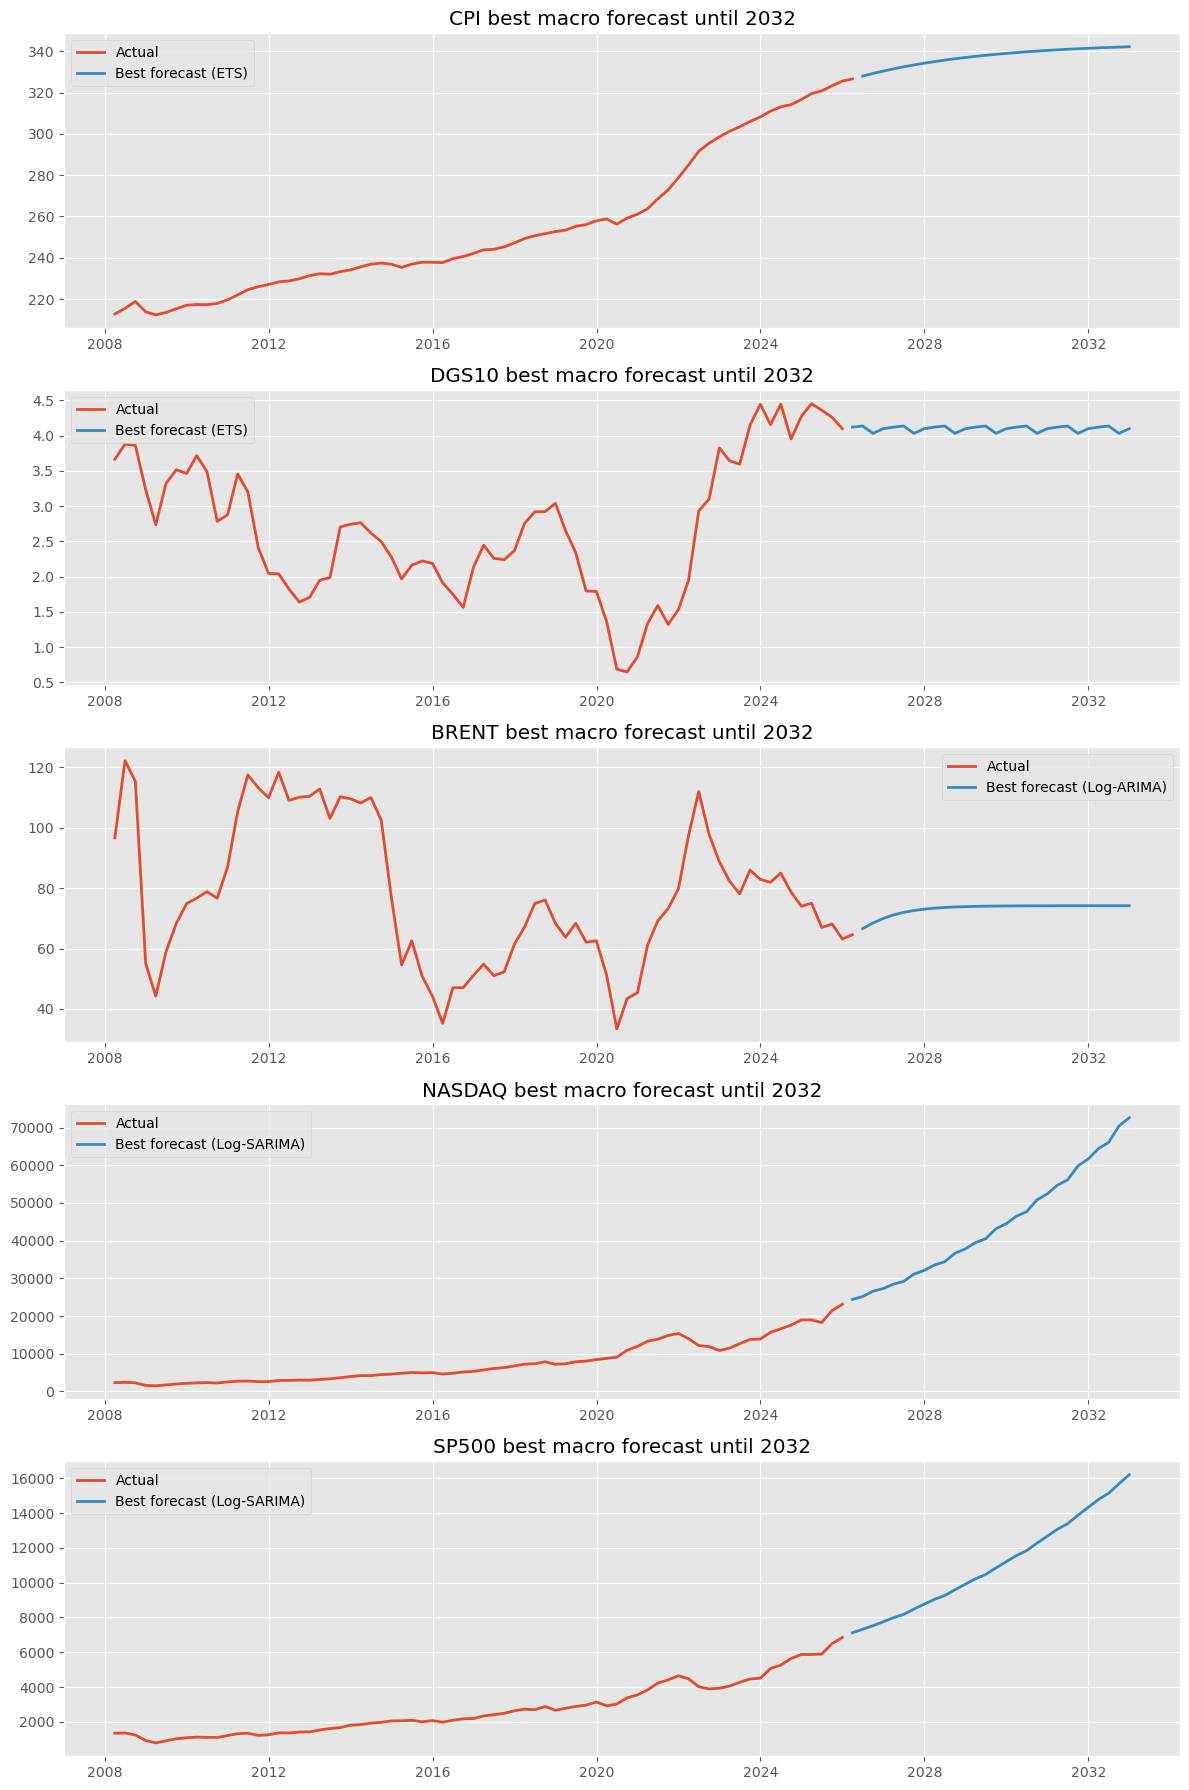

In [8]:
fig, axes = plt.subplots(len(indicator_cols), 1, figsize=(12, 18), sharex=False)

for ax, indicator in zip(axes, indicator_cols):
    actual = macro_quarterly[["date", indicator]].dropna()
    forecast = macro_ts_best_forecasts_2032_long[macro_ts_best_forecasts_2032_long["indicator"].eq(indicator)]
    best_model = best_macro_ts_models.loc[best_macro_ts_models["indicator"].eq(indicator), "model"].iloc[0]

    ax.plot(actual["date"], actual[indicator], label="Actual", linewidth=2)
    ax.plot(forecast["date"], forecast["predicted_value"], label=f"Best forecast ({best_model})", linewidth=2)
    ax.set_title(f"{indicator} best macro forecast until 2032")
    ax.legend()

plt.tight_layout()
plt.show()


## Final choice of the macro models

These are the models that are exported to the company models. The choice is fixed here instead of being re-selected on every run, so the main notebook always sees the same macro forecasts.

In [9]:
# Locked macro model selection for company forecasting
# These are the chosen macro forecasting models to export for the main company revenue notebook.

LOCKED_MACRO_MODEL_SELECTION = {
    "CPI": {
        "model": "ETS",
        "params": None,
        "candidate_set": ["ETS"],
    },
    "DGS10": {
        "model": "ETS",
        "params": None,
        "candidate_set": ["ETS"],
    },
    "BRENT": {
        "model": "Log-ARIMA",
        "params": {"order": (2, 0, 0)},
        "candidate_set": ["ARIMA", "Log-ARIMA"],
    },
    "NASDAQ": {
        "model": "Log-SARIMA",
        "params": {"order": (0, 1, 1), "seasonal_order": (1, 1, 1, 4)},
        "candidate_set": ["SARIMA", "Log-SARIMA", "Drift"],
    },
    "SP500": {
        "model": "Log-SARIMA",
        "params": {"order": (1, 1, 0), "seasonal_order": (1, 1, 1, 4)},
        "candidate_set": ["SARIMA", "Log-SARIMA", "ETS-trend"],
    },
}


# the locked models are trained up to 2025-12-31 (one quarter before this date) and forecast from 2026-03-31 on
LOCKED_MACRO_FORECAST_START_DATE = pd.Timestamp("2026-03-31")
LOCKED_MACRO_TRAIN_END_DATE = LOCKED_MACRO_FORECAST_START_DATE - pd.offsets.QuarterEnd()


def locked_future_quarter_dates(start_date=LOCKED_MACRO_FORECAST_START_DATE, end_date=FORECAST_END_DATE_2032):
    current = pd.Timestamp(start_date)
    dates = []
    while current <= pd.Timestamp(end_date):
        dates.append(current)
        current = current + pd.offsets.QuarterEnd()
    return pd.DatetimeIndex(dates)


def get_locked_ets_params(indicator, backtest_metrics):
    rows = backtest_metrics[
        backtest_metrics["indicator"].eq(indicator)
        & backtest_metrics["model"].eq("ETS")
    ]
    if rows.empty:
        return {"trend": "add", "seasonal": None, "seasonal_periods": None, "damped_trend": False}
    return rows.sort_values(METRIC_SORT_ORDER).iloc[0]["params"]


def coerce_forecast_values(pred, expected_steps, indicator, model_name):
    values = pd.to_numeric(pd.Series(np.asarray(pred, dtype=float).reshape(-1)), errors="coerce")
    values = values.replace([np.inf, -np.inf], np.nan).to_numpy(dtype=float)

    if len(values) != expected_steps:
        raise ValueError(f"{indicator} {model_name} returned {len(values)} values, expected {expected_steps}")

    if np.isnan(values).any():
        n_missing = int(np.isnan(values).sum())
        raise ValueError(f"{indicator} {model_name} returned {n_missing} NaN forecast values")

    return values


def locked_model_forecast(series, steps, model_name, params):
    # Statsmodels can behave better with a simple integer index for repeated notebook runs.
    fit_series = series.dropna().astype(float).reset_index(drop=True)

    if model_name == "ARIMA":
        return fit_arima_forecast(fit_series, steps, params["order"])
    if model_name == "SARIMA":
        return fit_sarima_forecast(fit_series, steps, params["order"], params["seasonal_order"])
    if model_name == "ETS":
        return fit_ets_forecast(fit_series, steps, params)
    if model_name == "Drift":
        return fit_drift_forecast(fit_series, steps)
    if model_name == "Log-ARIMA":
        return fit_log_arima_forecast(fit_series, steps, params["order"])
    if model_name == "Log-SARIMA":
        return fit_log_sarima_forecast(fit_series, steps, params["order"], params["seasonal_order"])
    raise ValueError(f"Unknown locked macro model: {model_name}")


def forecast_locked_macro_selection_until_2032(macro_df, locked_selection, backtest_metrics):
    rows = []
    diagnostics = []

    for indicator, spec in locked_selection.items():
        series = (
            macro_df.loc[pd.to_datetime(macro_df["date"]) <= LOCKED_MACRO_TRAIN_END_DATE]
            .set_index("date")[indicator]
            .dropna()
            .astype(float)
        )
        future_dates = locked_future_quarter_dates()
        model_name = spec["model"]
        params = spec["params"]

        if model_name == "ETS" and params is None:
            params = get_locked_ets_params(indicator, backtest_metrics)

        try:
            pred = locked_model_forecast(series, len(future_dates), model_name, params)
            pred = coerce_forecast_values(pred, len(future_dates), indicator, model_name)
            status = "ok"
            fallback_used = False
        # if a locked model fails to fit, fall back to a drift forecast so the export is not left with empty columns. The fallback is flagged in the diagnostics
        except Exception as exc:
            # Keep the export usable and visible rather than silently writing blank columns.
            # Drift fallback is marked in diagnostics and in the long output.
            print(f"Warning: {indicator} {model_name} failed ({exc}). Using drift fallback for export.")
            pred = fit_drift_forecast(series.reset_index(drop=True), len(future_dates))
            pred = coerce_forecast_values(pred, len(future_dates), indicator, "Drift fallback")
            status = f"fallback_drift: {exc}"
            fallback_used = True

        diagnostics.append({
            "indicator": indicator,
            "model": model_name,
            "params": params,
            "train_end_date": series.index.max(),
            "forecast_start_date": future_dates.min(),
            "forecast_end_date": future_dates.max(),
            "n_forecast_steps": len(future_dates),
            "n_missing_forecast_values": int(np.isnan(pred).sum()),
            "fallback_used": fallback_used,
            "status": status,
        })

        for date, predicted in zip(future_dates, pred):
            rows.append({
                "indicator": indicator,
                "date": date,
                "year": date.year,
                "quarter": date.quarter,
                "predicted_value": float(predicted),
                "model": model_name,
                "params": params,
                "candidate_set": spec["candidate_set"],
                "fallback_used": fallback_used,
                "forecast_type": "locked_macro_selection_until_2032",
            })

    long_df = pd.DataFrame(rows)
    diagnostics_df = pd.DataFrame(diagnostics)
    wide_df = (
        long_df
        .pivot_table(index=["date", "year", "quarter"], columns="indicator", values="predicted_value", aggfunc="first")
        .reset_index()
        .sort_values(["year", "quarter"])
        .reset_index(drop=True)
    )
    wide_df.columns.name = None

    for col in locked_selection.keys():
        if col not in wide_df.columns:
            wide_df[col] = np.nan

    wide_df = wide_df[["date", "year", "quarter"] + list(locked_selection.keys())]
    return long_df, wide_df, diagnostics_df


locked_macro_forecasts_2032_long, locked_macro_forecasts_2032_wide, locked_macro_forecast_diagnostics = forecast_locked_macro_selection_until_2032(
    macro_quarterly,
    LOCKED_MACRO_MODEL_SELECTION,
    macro_ts_backtest_metrics,
)

locked_macro_model_selection = pd.DataFrame([
    {
        "indicator": indicator,
        "model": spec["model"],
        "params": get_locked_ets_params(indicator, macro_ts_backtest_metrics) if spec["model"] == "ETS" and spec["params"] is None else spec["params"],
        "candidate_set": spec["candidate_set"],
    }
    for indicator, spec in LOCKED_MACRO_MODEL_SELECTION.items()
])

locked_macro_forecasts_2032_long.to_csv(
    RESULTS_DIR / "locked_macro_forecasts_until_2032_long.csv",
    index=False,
)
locked_macro_forecasts_2032_wide.to_csv(
    RESULTS_DIR / "locked_macro_forecasts_until_2032_wide.csv",
    index=False,
)
locked_macro_forecasts_2032_wide.to_csv(
    RESULTS_DIR / "macro_forecasts_for_company_models.csv",
    index=False,
)
locked_macro_model_selection.to_csv(
    RESULTS_DIR / "locked_macro_model_selection.csv",
    index=False,
)
locked_macro_forecast_diagnostics.to_csv(
    RESULTS_DIR / "locked_macro_forecast_diagnostics.csv",
    index=False,
)

print("Saved locked macro forecasts for company models to:")
print(RESULTS_DIR / "macro_forecasts_for_company_models.csv")
print("Missing values by exported column:")
print(locked_macro_forecasts_2032_wide.isna().sum())

display(locked_macro_forecast_diagnostics)
locked_macro_forecasts_2032_wide.head()



Saved locked macro forecasts for company models to:
experiment_results/macro_time_series_forecasts/macro_forecasts_for_company_models.csv
Missing values by exported column:
date       0
year       0
quarter    0
CPI        0
DGS10      0
BRENT      0
NASDAQ     0
SP500      0
dtype: int64


,indicator,model,params,train_end_date,forecast_start_date,forecast_end_date,n_forecast_steps,n_missing_forecast_values,fallback_used,status
0,CPI,ETS,"{'trend': 'add', 'seasonal': None, 'seasonal_p...",2025-12-31,2026-03-31,2032-12-31,28,0,False,ok
1,DGS10,ETS,"{'trend': None, 'seasonal': 'add', 'seasonal_p...",2025-12-31,2026-03-31,2032-12-31,28,0,False,ok
2,BRENT,Log-ARIMA,"{'order': (2, 0, 0)}",2025-12-31,2026-03-31,2032-12-31,28,0,False,ok
3,NASDAQ,Log-SARIMA,"{'order': (0, 1, 1), 'seasonal_order': (1, 1, ...",2025-12-31,2026-03-31,2032-12-31,28,0,False,ok
4,SP500,Log-SARIMA,"{'order': (1, 1, 0), 'seasonal_order': (1, 1, ...",2025-12-31,2026-03-31,2032-12-31,28,0,False,ok


,date,year,quarter,CPI,DGS10,BRENT,NASDAQ,SP500
0,2026-03-31,2026,1,327.487036,4.121844,63.611487,24407.275081,7121.906490
1,2026-06-30,2026,2,329.285897,4.137656,65.475270,25188.180747,7323.471514
2,2026-09-30,2026,3,330.953854,4.033394,67.458028,26591.230975,7526.663698
3,2026-12-31,2026,4,332.500436,4.100000,69.154235,27297.051430,7755.011672
4,2027-03-31,2027,1,333.934472,4.121844,70.485161,28473.939052,7987.766187


In [10]:
config = {
    "experiment": "macro_time_series_forecasts",
    "frequency": "quarterly",
    "aggregation": "quarterly mean of source observations",
    "indicators": indicator_cols,
    "models": ["ARIMA", "SARIMA", "ETS", "ETS-trend", "Drift", "Log-ARIMA", "Log-SARIMA"],
    "arima_grid": [list(order) for order in ARIMA_GRID],
    "sarima_grid": [
        {"order": list(item["order"]), "seasonal_order": list(item["seasonal_order"])}
        for item in SARIMA_GRID
    ],
    "ets_grid": ETS_GRID,
    "ets_trend_grid": ETS_TREND_GRID,
    "macro_model_candidates": MACRO_MODEL_CANDIDATES,
    "default_macro_model_candidates": DEFAULT_MACRO_MODEL_CANDIDATES,
    "drift_indicators": sorted(DRIFT_INDICATORS),
    "log_model_indicators": sorted(LOG_MODEL_INDICATORS),
    "tuning": "rolling-origin validation inside the training period",
    "backtest": "last 8 quarters holdout per macro indicator",
    "model_selection": "best model per indicator selected by sMAPE, then MAPE, RMSE, MAE",
    "locked_macro_model_selection": "CPI and DGS10 use ETS; BRENT uses Log-ARIMA(2,0,0); NASDAQ uses Log-SARIMA(0,1,1)(1,1,1,4); SP500 uses Log-SARIMA(1,1,0)(1,1,1,4).",
    "forecast_end_date": str(FORECAST_END_DATE_2032.date()),
    "outputs": [
        "macro_quarterly_actuals.csv",
        "macro_ts_backtest_predictions.csv",
        "macro_ts_backtest_metrics.csv",
        "macro_ts_tuning_results.csv",
        "macro_ts_forecasts_until_2032_long.csv",
        "macro_ts_best_forecasts_until_2032_long.csv",
        "macro_ts_best_forecasts_until_2032_wide.csv",
        "macro_ts_best_models_by_indicator.csv",
        "locked_macro_forecasts_until_2032_long.csv",
        "locked_macro_forecasts_until_2032_wide.csv",
        "macro_forecasts_for_company_models.csv",
        "locked_macro_model_selection.csv",
        "locked_macro_forecast_diagnostics.csv",
    ],
}

with open(RESULTS_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved macro time-series outputs to:", RESULTS_DIR.resolve())






Saved macro time-series outputs to: experiment_results/macro_time_series_forecasts


## Checks and summary

In [11]:
# the validation fold must start strictly after its training fold ends
# 1. Data leakage check for rolling-origin macro validation splits
_macro_leakage_rows = []
_macro_backtest_n_test = 8
if "macro_ts_backtest_metrics" in globals() and "n_test_points" in macro_ts_backtest_metrics.columns:
    _n_test_values = pd.to_numeric(macro_ts_backtest_metrics["n_test_points"], errors="coerce").dropna()
    if not _n_test_values.empty:
        _macro_backtest_n_test = int(_n_test_values.max())

for _indicator in indicator_cols:
    _series = macro_quarterly.set_index("date")[_indicator].dropna().astype(float)
    _train_series = _series.iloc[:-_macro_backtest_n_test]
    _splits = rolling_splits(_train_series, n_splits=3, horizon=4, min_train=24)

    for _fold, _fold_train, _fold_valid in _splits:
        _train_end = pd.Timestamp(_fold_train.index.max())
        _val_start = pd.Timestamp(_fold_valid.index.min())
        _val_end = pd.Timestamp(_fold_valid.index.max())
        _macro_leakage_rows.append({
            "indicator": _indicator,
            "split": _fold,
            "train_end_date": _train_end,
            "val_start_date": _val_start,
            "val_end_date": _val_end,
            "no_leakage": _train_end < _val_start,
        })

macro_rolling_split_leakage_check = pd.DataFrame(_macro_leakage_rows)
print(macro_rolling_split_leakage_check.to_string(index=False))

assert not macro_rolling_split_leakage_check.empty, "No rolling-origin splits were generated."
assert macro_rolling_split_leakage_check["no_leakage"].all(), "Leakage detected: validation starts before or at train end."
print("PASS: every validation fold starts strictly after its training fold ends.")


indicator  split train_end_date val_start_date val_end_date  no_leakage
      CPI      1     2021-03-31     2021-06-30   2022-03-31        True
      CPI      2     2022-03-31     2022-06-30   2023-03-31        True
      CPI      3     2023-03-31     2023-06-30   2024-03-31        True
    DGS10      1     2020-12-31     2021-03-31   2021-12-31        True
    DGS10      2     2021-12-31     2022-03-31   2022-12-31        True
    DGS10      3     2022-12-31     2023-03-31   2023-12-31        True
    BRENT      1     2021-03-31     2021-06-30   2022-03-31        True
    BRENT      2     2022-03-31     2022-06-30   2023-03-31        True
    BRENT      3     2023-03-31     2023-06-30   2024-03-31        True
   NASDAQ      1     2020-12-31     2021-03-31   2021-12-31        True
   NASDAQ      2     2021-12-31     2022-03-31   2022-12-31        True
   NASDAQ      3     2022-12-31     2023-03-31   2023-12-31        True
    SP500      1     2020-12-31     2021-03-31   2021-12-31     

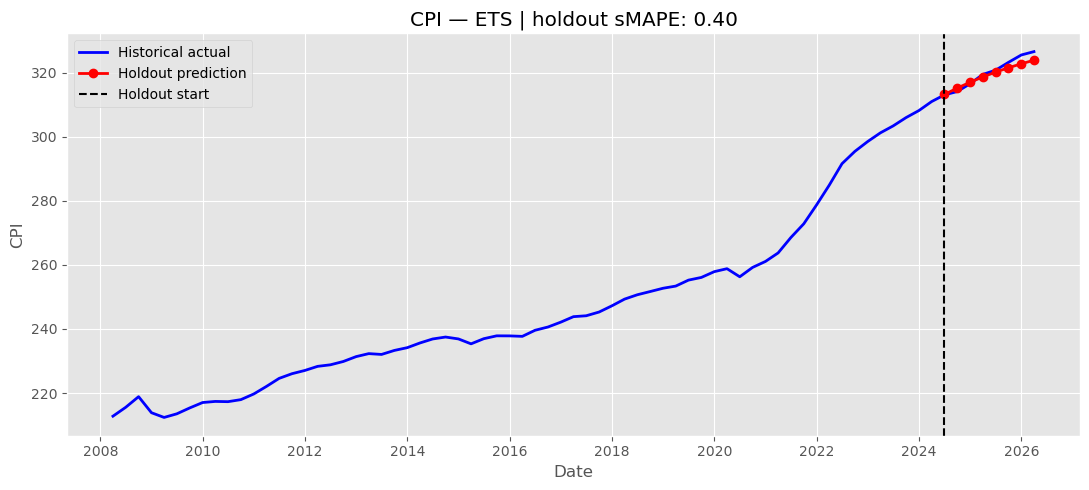

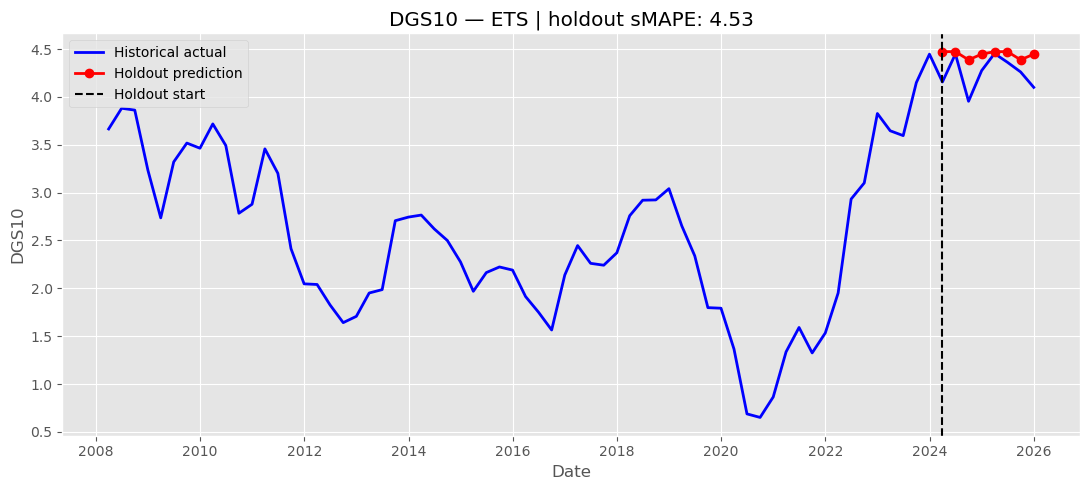

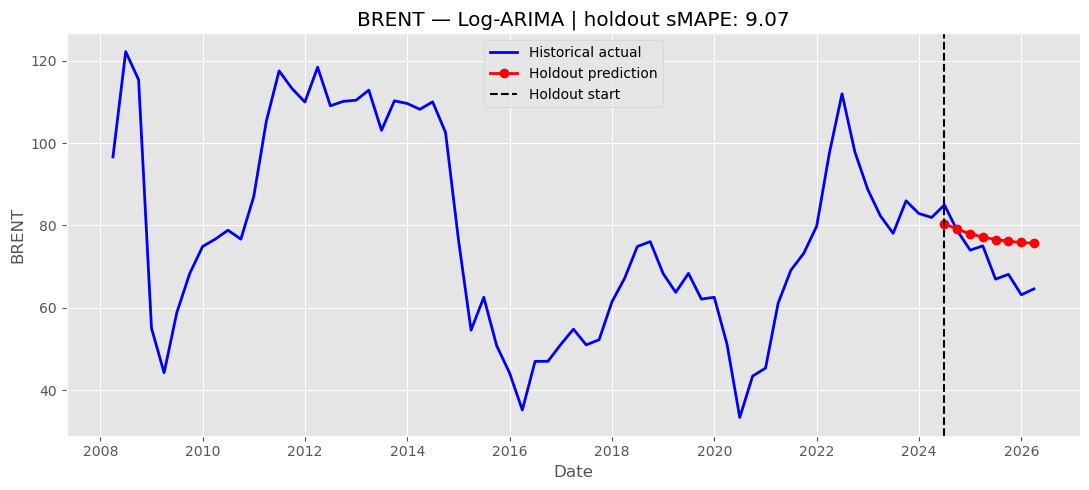

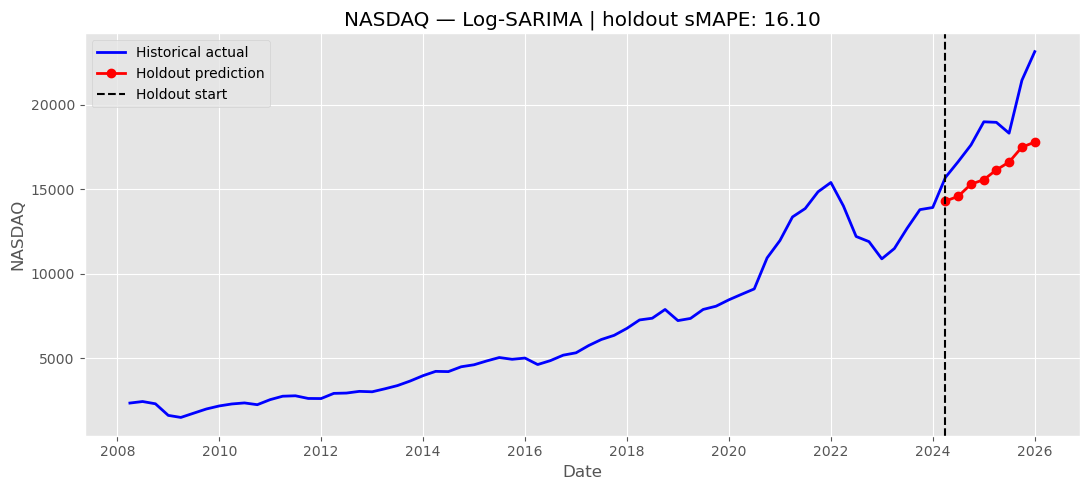

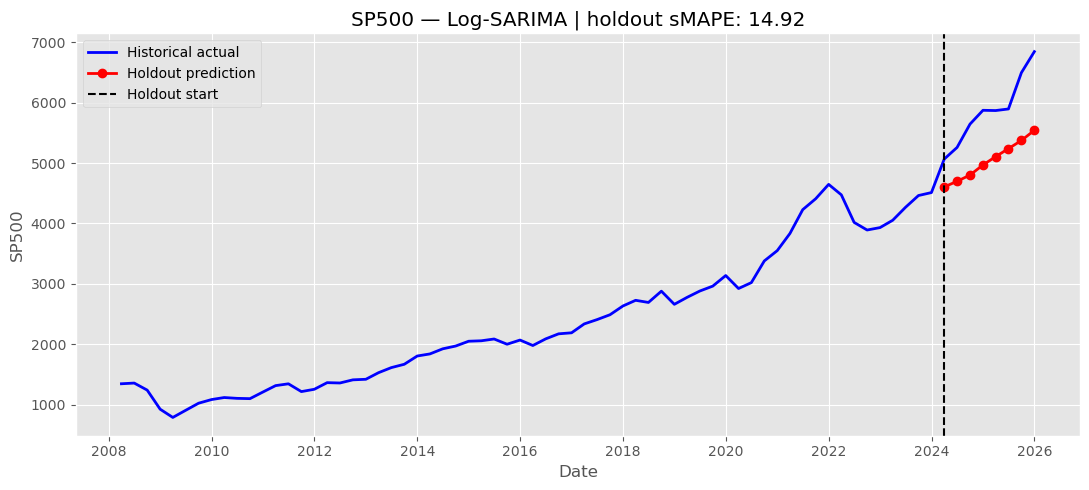

In [12]:
# 2. Backtest visualization: full history plus last-8-quarter holdout predictions
plt.style.use("ggplot")

_macro_metric_sort_cols = [col for col in ["sMAPE", "MAPE", "RMSE", "MAE"] if col in macro_ts_backtest_metrics.columns]
_macro_best_backtest_rows = (
    macro_ts_backtest_metrics
    .sort_values(["indicator"] + _macro_metric_sort_cols)
    .groupby("indicator", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

for _indicator in indicator_cols:
    _actual = (
        macro_quarterly[["date", _indicator]]
        .dropna()
        .assign(date=lambda df: pd.to_datetime(df["date"]))
        .sort_values("date")
    )
    _best = _macro_best_backtest_rows.loc[_macro_best_backtest_rows["indicator"].eq(_indicator)].iloc[0]
    _best_model_name = _best["model"]
    _best_smape = float(_best["sMAPE"])
    _pred = (
        macro_ts_backtest_predictions[
            macro_ts_backtest_predictions["indicator"].eq(_indicator)
            & macro_ts_backtest_predictions["model"].eq(_best_model_name)
        ]
        .assign(date=lambda df: pd.to_datetime(df["date"]))
        .sort_values("date")
    )

    _split_point = _pred["date"].min()

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(_actual["date"], _actual[_indicator], color="blue", linewidth=2, label="Historical actual")
    ax.plot(_pred["date"], _pred["predicted"], color="red", marker="o", linewidth=2, label="Holdout prediction")
    ax.axvline(_split_point, color="black", linestyle="--", linewidth=1.5, label="Holdout start")
    ax.set_title(f"{_indicator} — {_best_model_name} | holdout sMAPE: {_best_smape:.2f}")
    ax.set_xlabel("Date")
    ax.set_ylabel(_indicator)
    ax.legend()
    plt.tight_layout()
    plt.show()


In [13]:
# 3. Backtest metrics summary table
_macro_backtest_summary_cols = ["indicator", "model", "params", "MAE", "RMSE", "MAPE", "sMAPE", "n_test_points"]
macro_backtest_summary = (
    macro_ts_backtest_metrics[_macro_backtest_summary_cols]
    .copy()
    .sort_values("sMAPE", ascending=True)
    .reset_index(drop=True)
)

print(macro_backtest_summary.to_string(index=False))
macro_backtest_summary.to_csv(RESULTS_DIR / "macro_backtest_summary.csv", index=False)
print("Saved:", RESULTS_DIR / "macro_backtest_summary.csv")


indicator      model                                                                             params         MAE        RMSE      MAPE     sMAPE  n_test_points
      CPI        ETS {'trend': 'add', 'seasonal': None, 'seasonal_periods': None, 'damped_trend': True}    1.272014    1.581239  0.393996  0.395008              8
      CPI      ARIMA                                                               {'order': (3, 1, 0)}    1.414970    1.773847  0.438035  0.439374              8
      CPI     SARIMA                               {'order': (1, 1, 0), 'seasonal_order': (1, 0, 0, 4)}    1.539151    1.900581  0.477147  0.478512              8
    DGS10        ETS   {'trend': None, 'seasonal': 'add', 'seasonal_periods': 4, 'damped_trend': False}    0.193903    0.241705  4.697578  4.528891              8
    DGS10     SARIMA                               {'order': (0, 1, 1), 'seasonal_order': (0, 0, 0, 4)}    0.236380    0.287157  5.717972  5.481636              8
    BRENT  Log-ARIMA  

In [14]:
# 4. Standalone macro lag-1 feature check for Diplomwork_before_linear_regression.ipynb
# Copy-paste this cell into notebook 2 after the macro-enhanced company DataFrames are created.
_macro_lag_cols = ["CPI", "DGS10", "BRENT", "NASDAQ", "SP500"]

# this only makes sense inside the main notebook (needs data_qc and macro), otherwise the cell just skips
if "data_qc" not in globals() or "macro" not in globals():
    print("SKIP: this standalone check is intended to run in notebook 2 after `data_qc` and `macro` exist.")
else:
    def _with_year_quarter_period(_df):
        _out = _df.copy()
        if "year" not in _out.columns:
            if "fiscal_year" in _out.columns:
                _out["year"] = _out["fiscal_year"]
            else:
                _out["year"] = pd.to_datetime(_out["date"]).dt.year
        if "quarter" not in _out.columns:
            if "fiscal_quarter" in _out.columns:
                _out["quarter"] = _out["fiscal_quarter"]
            else:
                _out["quarter"] = pd.to_datetime(_out["date"]).dt.quarter
        _out["year"] = pd.to_numeric(_out["year"], errors="coerce")
        _out["quarter"] = pd.to_numeric(_out["quarter"], errors="coerce")
        _out = _out.dropna(subset=["year", "quarter"]).copy()
        _out["year"] = _out["year"].astype(int)
        _out["quarter"] = _out["quarter"].astype(int)
        _out["_macro_period"] = pd.PeriodIndex(year=_out["year"], quarter=_out["quarter"], freq="Q")
        return _out

    _macro_actuals = _with_year_quarter_period(macro)
    _macro_actuals = _macro_actuals.sort_values("_macro_period").copy()
    _macro_actuals[_macro_lag_cols] = _macro_actuals[_macro_lag_cols].replace([np.inf, -np.inf], np.nan).ffill().bfill()
    _macro_actuals = _macro_actuals.drop_duplicates("_macro_period", keep="last")
    _macro_actuals["_expected_period"] = _macro_actuals["_macro_period"] + 1
    _expected_lag1 = _macro_actuals[["_expected_period"] + _macro_lag_cols].rename(columns={"_expected_period": "_macro_period"})

    _candidate_frame_names = [
        "ml_raw_macro",
        "ml_log_macro",
        "ml_log_micro_macro",
        "data_qc_with_period",
        "data_qc",
    ]
    _candidate_frame_name = None
    _candidate_frame = None
    for _name in _candidate_frame_names:
        _obj = globals().get(_name)
        if isinstance(_obj, pd.DataFrame) and "company" in _obj.columns and all(col in _obj.columns for col in _macro_lag_cols):
            _candidate_frame_name = _name
            _candidate_frame = _obj
            break

    if _candidate_frame is None:
        print("FAIL: no merged company DataFrame with company and macro columns was found.")
    else:
        print(f"Checking lag-1 macro alignment in `{_candidate_frame_name}`")
        _company_macro = _with_year_quarter_period(_candidate_frame)
        _company_macro = _company_macro.merge(_expected_lag1, on="_macro_period", how="left", suffixes=("", "_expected_lag1"))

        _rows = []
        for _company, _company_df in _company_macro.groupby("company", sort=True):
            _observed = _company_df[_macro_lag_cols].apply(pd.to_numeric, errors="coerce")
            _expected = _company_df[[f"{col}_expected_lag1" for col in _macro_lag_cols]].apply(pd.to_numeric, errors="coerce")
            _expected.columns = _macro_lag_cols
            _valid = _observed.notna().all(axis=1) & _expected.notna().all(axis=1)

            if int(_valid.sum()) == 0:
                _rows.append({
                    "company": _company,
                    "status": "FAIL",
                    "checked_rows": 0,
                    "mismatch_rows": 0,
                    "mismatch_cells": 0,
                    "note": "no comparable lag-1 rows",
                })
                continue

            _mismatch_matrix = ~np.isclose(
                _observed.loc[_valid].to_numpy(dtype=float),
                _expected.loc[_valid].to_numpy(dtype=float),
                rtol=1e-6,
                atol=1e-8,
                equal_nan=True,
            )
            _mismatch_rows = int(_mismatch_matrix.any(axis=1).sum())
            _mismatch_cells = int(_mismatch_matrix.sum())
            _rows.append({
                "company": _company,
                "status": "PASS" if _mismatch_rows == 0 else "FAIL",
                "checked_rows": int(_valid.sum()),
                "mismatch_rows": _mismatch_rows,
                "mismatch_cells": _mismatch_cells,
                "note": "",
            })

        macro_lag1_check_summary = pd.DataFrame(_rows).sort_values(["status", "company"]).reset_index(drop=True)
        print(macro_lag1_check_summary.to_string(index=False))


SKIP: this standalone check is intended to run in notebook 2 after `data_qc` and `macro` exist.
